# SDC Testing Challenge — Test Prioritization

Welcome to the **Self-Driving Car (SDC) Testing Challenge**.

Your job is to **decide the order** in which a set of simulator-based driving tests should be executed, so that **failing tests (the car drives off the lane) appear as early as possible**. The earlier you find failures, the less simulation time is wasted before a problem is discovered.

This challenge mirrors the **2026 ICST/SBFT SDC Testing Tool Competition** ([info](https://conf.researchr.org/track/icst-2025/icst-2025-tool-competition--self-driving-car-testing) · [repo](https://github.com/christianbirchler-org/sdc-testing-competition)). The algorithmic task and evaluation metric are identical; only the packaging (gRPC + Docker + simulator DB) has been replaced with a local Python notebook.

Read the companion document `../1_challenge_guide.md` first — it explains the background and metrics in more depth.

## 1. Setup

Load the dataset and split it into:
- **train** — test cases **with** their ground-truth label (`has_failed`). You may use these to learn patterns.
- **test_suite** — test cases **without** labels. This is what your prioritizer will reorder.
- **ground_truth** — held only by the evaluator. Don't peek at it from inside your prioritizer.

In [1]:
import sys
from pathlib import Path

# Make `sdc_lib` importable from inside the exercises/ folder
CHALLENGE_ROOT = Path.cwd().parent
sys.path.insert(0, str(CHALLENGE_ROOT))

from sdc_lib import (
    load_dataset, split_train_test,
    evaluate,
    RandomPrioritizer, IdentityPrioritizer,
    plot_road, plot_roads_grid, plot_fault_detection_curve, plot_top_picks,
)

raw_records = load_dataset(CHALLENGE_ROOT / "data" / "sdc-test-data.json")
train_oracles, test_suite, ground_truth = split_train_test(
    raw_records, train_ratio=0.2, seed=42,
)

print(f"Total test cases in dataset : {len(raw_records)}")
print(f"Train (with oracle)         : {len(train_oracles)} cases")
print(f"Test suite (oracle hidden)  : {len(test_suite)} cases")
print()
print(f"Sample train oracle entry   : {train_oracles[0]!r}"[:120] + " ...")
print(f"Sample test_suite entry     : {test_suite[0]!r}"[:120] + " ...")

Total test cases in dataset : 956
Train (with oracle)         : 191 cases
Test suite (oracle hidden)  : 765 cases

Sample train oracle entry   : OracleEntry(test_case=SDCTestCase(test_id='65ca1db216ba3922d7ad22db', road_points=[(61.737 ...
Sample test_suite entry     : SDCTestCase(test_id='65ca1da416ba3922d7ad2212', road_points=[(36.47449848798576, 10), (36. ...


## 2. Explore the data

We first look at **what the three variables actually contain** (their internal fields and shapes), then **what the roads themselves look like** as 2D shapes.

### 2.1 What's inside `train_oracles`, `test_suite`, `ground_truth`?

These are the three variables you will work with throughout the challenge. They are intentionally shaped to mirror what your prioritizer would receive in the real ICST competition: `train_oracles` carries labels (for `initialize()`), `test_suite` does **not** carry labels (this is what `prioritize()` receives), and `ground_truth` is held by the evaluator only.

> 🤝 **Honor code — do not access `ground_truth` from inside your prioritizer.**
>
> `ground_truth` is the answer key: it tells the evaluator whether each test in `test_suite` actually failed. Touching it from inside `MyPrioritizer.initialize()` or `MyPrioritizer.prioritize()` is the same as reading the answers during an exam — your APFD will look perfect but mean nothing, and you'll learn nothing.
>
> **The promise:** inside your prioritizer, use only what is handed to you — `oracles` in `initialize()`, `test_suite` in `prioritize()`. Pretend `ground_truth` does not exist in the notebook's namespace.

In [2]:
# ---------------------------------------------------------------------
# 1) train_oracles  →  list[OracleEntry]
# ---------------------------------------------------------------------
print("=" * 70)
print(f"train_oracles  :  list[OracleEntry]   (length = {len(train_oracles)})")
print("=" * 70)
print("OracleEntry has two fields:")
print("  .test_case   : SDCTestCase")
print("       .test_id     : str")
print("       .road_points : list[tuple[float, float]]")
print("  .has_failed  : bool      ← the label (visible here, hidden in test_suite)")
e = train_oracles[0]
print("\nsample = train_oracles[0]:")
print(f"  .test_case.test_id     = {e.test_case.test_id!r}")
print(f"  .test_case.road_points = list of {len(e.test_case.road_points)} (x,y) tuples")
print(f"                           first 2: {e.test_case.road_points[:2]}")
print(f"  .has_failed            = {e.has_failed}")

# ---------------------------------------------------------------------
# 2) test_suite  →  list[SDCTestCase]
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"test_suite  :  list[SDCTestCase]   (length = {len(test_suite)})")
print("=" * 70)
print("Each element is an SDCTestCase. The has_failed label is intentionally NOT here.")
print("SDCTestCase fields:")
print("  .test_id     : str")
print("  .road_points : list[tuple[float, float]]")
tc = test_suite[0]
print("\nsample = test_suite[0]:")
print(f"  .test_id     = {tc.test_id!r}")
print(f"  .road_points = list of {len(tc.road_points)} (x,y) tuples")
print(f"                 first 2: {tc.road_points[:2]}")
print("  .has_failed  →  AttributeError (label hidden from prioritizer)")

train_oracles  :  list[OracleEntry]   (length = 191)
OracleEntry has two fields:
  .test_case   : SDCTestCase
       .test_id     : str
       .road_points : list[tuple[float, float]]
  .has_failed  : bool      ← the label (visible here, hidden in test_suite)

sample = train_oracles[0]:
  .test_case.test_id     = '65ca1db216ba3922d7ad22db'
  .test_case.road_points = list of 197 (x,y) tuples
                           first 2: [(61.73701496868533, 24.327004121514108), (61.82311329854664, 25.826776410830448)]
  .has_failed            = False

test_suite  :  list[SDCTestCase]   (length = 765)
Each element is an SDCTestCase. The has_failed label is intentionally NOT here.
SDCTestCase fields:
  .test_id     : str
  .road_points : list[tuple[float, float]]

sample = test_suite[0]:
  .test_id     = '65ca1da416ba3922d7ad2212'
  .road_points = list of 197 (x,y) tuples
                 first 2: [(36.47449848798576, 10), (36.50342554627075, 11.360301367561368)]
  .has_failed  →  AttributeError (l

### 2.2 What do the roads look like?

A test case is a sequence of 2D road points. In the simulator, the car drives from the first point onward, following the curve they trace out.

Let's eyeball a few **passing** and **failing** roads side-by-side. Build intuition first — your prioritization heuristic will be much better if you can predict *what kind of road tends to make the car go off-lane*.

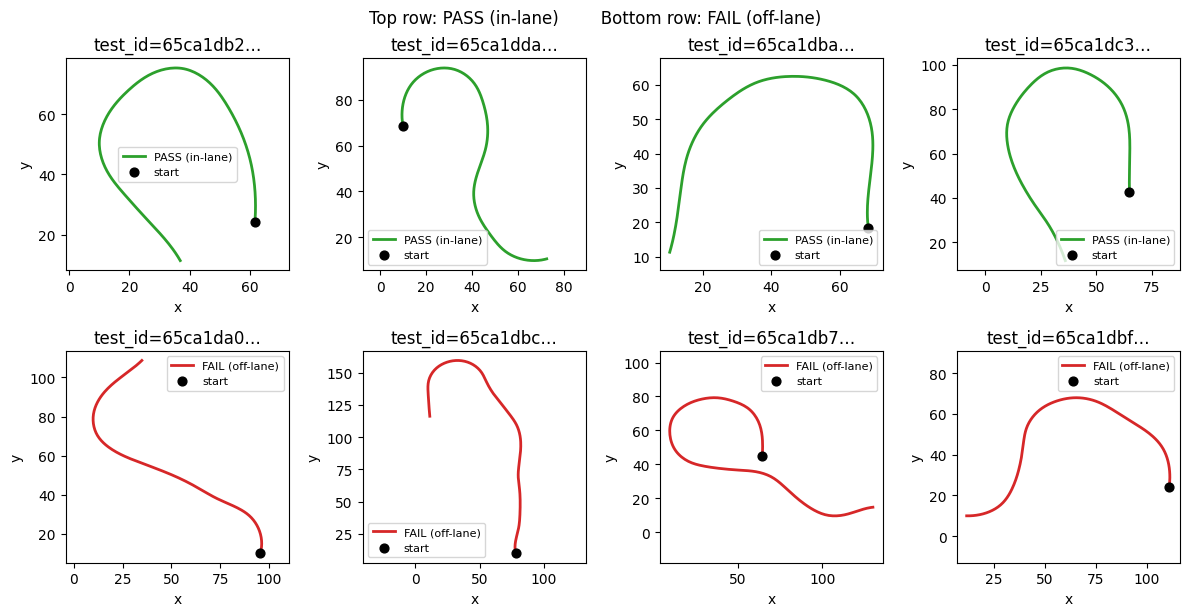

train: 70/191 failing (36.6%)
test : 283/765 failing  (37.0%)
road points per test case: 197–197


In [3]:
import matplotlib.pyplot as plt

passing = [e for e in train_oracles if not e.has_failed][:4]
failing = [e for e in train_oracles if e.has_failed][:4]

fig = plot_roads_grid(passing + failing, n_cols=4)
fig.suptitle("Top row: PASS (in-lane)        Bottom row: FAIL (off-lane)", fontsize=12, y=1.02)
plt.show()

# Some descriptive stats
n_fail_train = sum(1 for e in train_oracles if e.has_failed)
n_fail_test  = sum(1 for v in ground_truth.values() if v["has_failed"])
rp_counts    = [len(e.test_case.road_points) for e in train_oracles]
print(f"train: {n_fail_train}/{len(train_oracles)} failing ({n_fail_train/len(train_oracles):.1%})")
print(f"test : {n_fail_test}/{len(test_suite)} failing  ({n_fail_test/len(test_suite):.1%})")
print(f"road points per test case: {min(rp_counts)}–{max(rp_counts)}")

## 3. Baselines

Two trivial prioritizers to compare against:

- **RandomPrioritizer** — shuffles the test suite. This is the official sample tool that ships with the ICST competition repo. Expected `APFD ≈ 0.5`.
- **IdentityPrioritizer** — keeps the test suite in its original order. Also expected near 0.5 because the order is already arbitrary.

**Any worthwhile heuristic should beat 0.5.**

=== Evaluation report: RandomPrioritizer ===
  test suite size      : 765
  failing tests in suite: 283
  APFD                 : 0.4888   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.4842
  Time-to-first-fault  : 56.8 s
  Time-to-last-fault   : 65112.2 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.2 ms

=== Evaluation report: IdentityPrioritizer ===
  test suite size      : 765
  failing tests in suite: 283
  APFD                 : 0.5059   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.5143
  Time-to-first-fault  : 374.1 s
  Time-to-last-fault   : 65112.2 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.0 ms


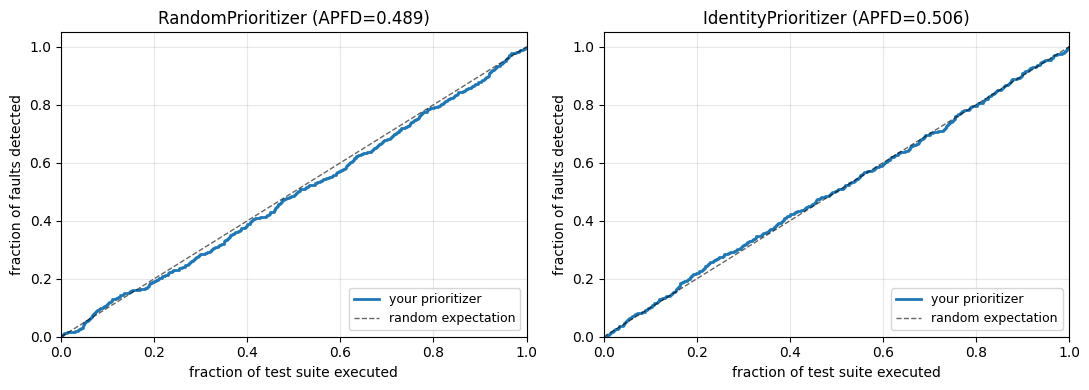

In [4]:
report_random   = evaluate(RandomPrioritizer(seed=0), train_oracles, test_suite, ground_truth)
report_identity = evaluate(IdentityPrioritizer(),     train_oracles, test_suite, ground_truth)

print(report_random)
print()
print(report_identity)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_fault_detection_curve(report_random.failed_positions,   report_random.n_tests,
                           title=f"RandomPrioritizer (APFD={report_random.apfd:.3f})",   ax=axes[0])
plot_fault_detection_curve(report_identity.failed_positions, report_identity.n_tests,
                           title=f"IdentityPrioritizer (APFD={report_identity.apfd:.3f})", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Your turn — implement `MyPrioritizer`

Fill in the two methods below.

### Required interface
```python
class MyPrioritizer:
    def initialize(self, oracles: list[OracleEntry]) -> None:
        # (optional) learn from training data here.
        # `oracles` is a list of (SDCTestCase, has_failed) pairs.
        ...

    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        # MUST return the test_ids in priority order — a permutation of the input ids.
        # The earlier a failing test appears in this list, the higher your APFD.
        ...
```

### Validity rules (enforced by the evaluator)
1. Every `test_id` in `test_suite` must appear **exactly once** in your output.
2. No unknown ids, no duplicates, no missing ids.

### Ideas to try (from simplest to most ambitious)
- **Sort by total road length** — longer roads have more chances to go off-lane.
- **Sort by total curvature** — sharper turns tend to push the car off-lane.
- **Sort by maximum local turn angle** — even one tight corner can cause failure.
- **Train a classifier** on `train_oracles` (sklearn `RandomForestClassifier` etc.) using engineered features per road, then sort the test suite by predicted failure probability.
- **Combine signals** — e.g., weight curvature × length.

> 💡 If you don't want to compute road features from scratch, an **unofficial** `sdc_lib.features` module ships a handful of quick approximations (length, turn angles, sharp-turn count, bounding box area). See Section 6 for the disclaimer and a worked example using it.

The skeleton below ships with a trivial identity ordering so the notebook runs end-to-end out of the box. Replace it with your own logic.

In [5]:
from sdc_lib import SDCTestCase, OracleEntry


class MyPrioritizer:
    """My SDC test prioritizer — fill in `prioritize` (and optionally `initialize`)."""

    def initialize(self, oracles: list[OracleEntry]) -> None:
        # OPTIONAL: learn something from the labelled training data.
        # Example (commented):
        #   self.avg_fail_len = sum(len(e.test_case.road_points) for e in oracles if e.has_failed) / ...
        pass

    def prioritize(self, test_suite: list[SDCTestCase]) -> list[str]:
        # TODO: replace this trivial ordering with your own ranking logic.
        return [tc.test_id for tc in test_suite]

## 5. Run your prioritizer

Run this cell after every change. Try to push APFD above 0.6, then above 0.7.

=== Evaluation report: MyPrioritizer ===
  test suite size      : 765
  failing tests in suite: 283
  APFD                 : 0.5059   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.5143
  Time-to-first-fault  : 374.1 s
  Time-to-last-fault   : 65112.2 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 0.1 ms


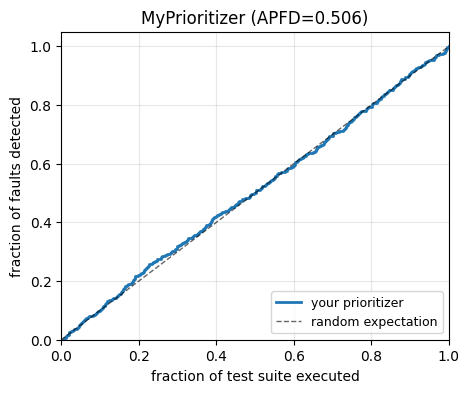

In [6]:
my_report = evaluate(MyPrioritizer(), train_oracles, test_suite, ground_truth, tool_name="MyPrioritizer")
print(my_report)

plot_fault_detection_curve(
    my_report.failed_positions, my_report.n_tests,
    title=f"MyPrioritizer (APFD={my_report.apfd:.3f})",
)
plt.show()

### 5.1 Inspect what your prioritizer ranked at the top

Pull the test cases your prioritizer put first and draw their road shapes — useful for debugging.
If your top picks turn out to be **PASS (green)** roads, your ranking signal is misaligned with what actually fails.

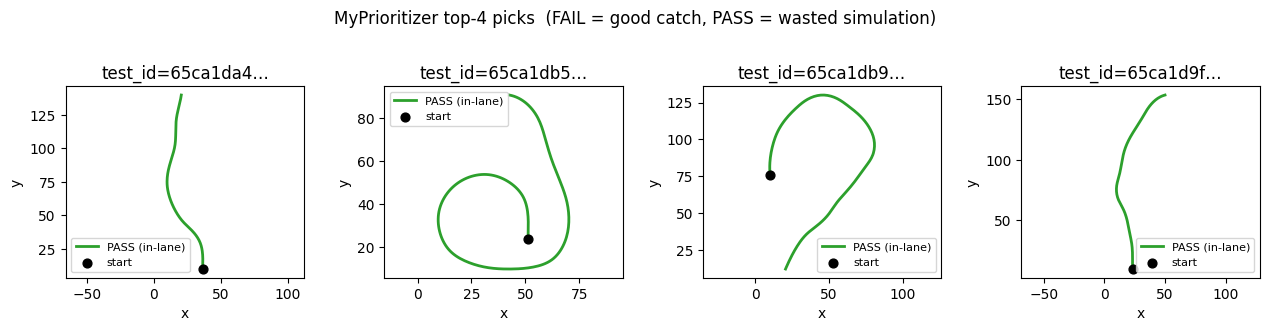

In [7]:
# Inspect MyPrioritizer's top picks.
# Swap the first argument to inspect a different report
# (e.g. report_length, report_random, report_identity).
plot_top_picks(my_report, test_suite, ground_truth, k=4)
plt.show()

## 6. Optional helpers + worked example

The `sdc_lib.features` module ships a handful of helper functions for computing geometric features from a road:

```python
from sdc_lib.features import (
    total_length,        # Euclidean length of the polyline
    mean_turn_angle,     # average absolute turn angle (radians)
    max_turn_angle,      # largest single turn angle (radians)
    total_turn_angle,    # sum of absolute turn angles — crude 'total curvature'
    num_sharp_turns,     # count of turns exceeding a threshold (default 10°)
    bounding_box_area,   # area of axis-aligned bounding box
)
```

> ⚠️ **Disclaimer — this module is UNOFFICIAL support.**
>
> It is **not** part of the ICST/SBFT competition. The values these helpers return are **quick approximations**, not exact geometric quantities — they are sensitive to road sampling density, use unsigned angles, ignore rotation in the bounding box, and so on. Treat them as a low-friction starting point: **for stronger signal, implement your own (smarter, more accurate) versions.**

### Helper output on a single test case

To get a feel for what each helper produces, the cell below picks one road and runs every helper on it — printing the value next to a 2D plot of the road.

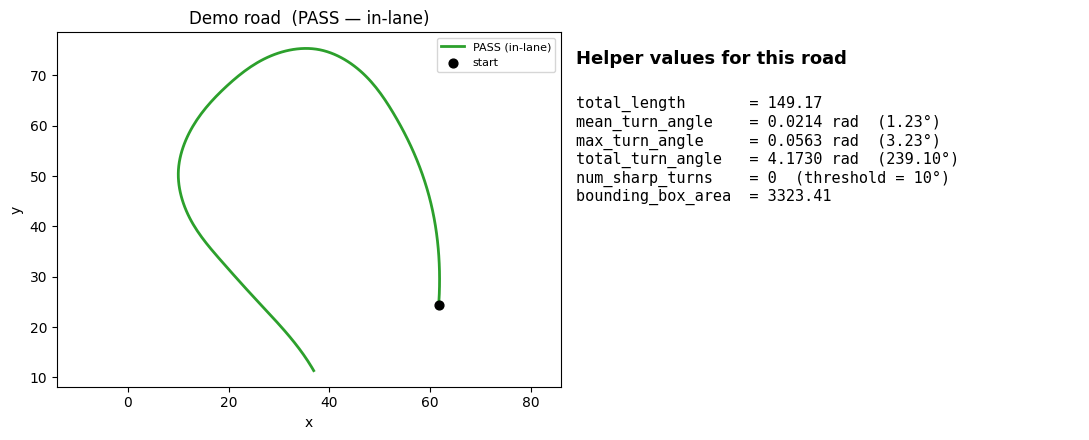

In [8]:
from sdc_lib.features import (
    total_length, mean_turn_angle, max_turn_angle,
    total_turn_angle, num_sharp_turns, bounding_box_area,
)
import math

# Pick a single test case to demo every helper on.
demo_entry = train_oracles[0]
tc = demo_entry.test_case
rp = tc.road_points

values = {
    "total_length":      f"{total_length(rp):.2f}",
    "mean_turn_angle":   f"{mean_turn_angle(rp):.4f} rad  ({math.degrees(mean_turn_angle(rp)):.2f}°)",
    "max_turn_angle":    f"{max_turn_angle(rp):.4f} rad  ({math.degrees(max_turn_angle(rp)):.2f}°)",
    "total_turn_angle":  f"{total_turn_angle(rp):.4f} rad  ({math.degrees(total_turn_angle(rp)):.2f}°)",
    "num_sharp_turns":   f"{num_sharp_turns(rp)}  (threshold = 10°)",
    "bounding_box_area": f"{bounding_box_area(rp):.2f}",
}

# Side-by-side: road shape on the left, helper values on the right.
fig, (ax_road, ax_text) = plt.subplots(1, 2, figsize=(11, 4.5))
plot_road(tc, has_failed=demo_entry.has_failed, ax=ax_road)
ax_road.set_title(
    f"Demo road  ({'FAIL — off-lane' if demo_entry.has_failed else 'PASS — in-lane'})"
)

ax_text.axis("off")
ax_text.text(0.0, 0.95, "Helper values for this road",
             fontsize=13, fontweight="bold", va="top", transform=ax_text.transAxes)
ax_text.text(0.0, 0.82,
             "\n".join(f"{k:<18} = {v}" for k, v in values.items()),
             fontsize=11, family="monospace", va="top", transform=ax_text.transAxes)

fig.tight_layout(); plt.show()

### Worked example: what if we sort by `total_length` only?

The simplest possible heuristic — pick one helper, sort the test suite by it. Longer roads have more chance to drift off-lane, so we try **longest first**.

=== Evaluation report: LengthPrioritizer ===
  test suite size      : 765
  failing tests in suite: 283
  APFD                 : 0.5948   (1.0 = best, 0.0 = worst, ~0.5 = random)
  APFDC (cost-aware)   : 0.5711
  Time-to-first-fault  : 424.9 s
  Time-to-last-fault   : 65112.2 s
  initialize() runtime : 0.0 ms
  prioritize() runtime : 26.0 ms


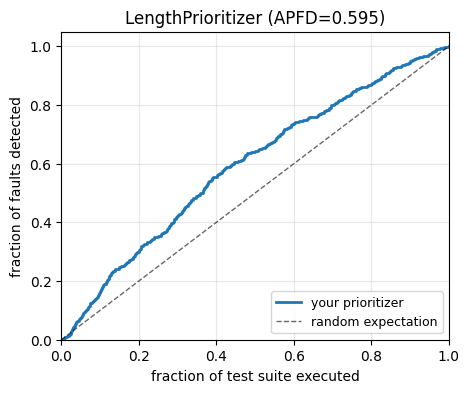

In [9]:
from sdc_lib.features import total_length


class LengthPrioritizer:
    """Sort by `total_length` only — longest road first."""

    def initialize(self, oracles): pass

    def prioritize(self, test_suite):
        ranked = sorted(test_suite, key=lambda tc: -total_length(tc.road_points))
        return [tc.test_id for tc in ranked]


report_length = evaluate(LengthPrioritizer(), train_oracles, test_suite, ground_truth)
print(report_length)
plot_fault_detection_curve(
    report_length.failed_positions, report_length.n_tests,
    title=f"LengthPrioritizer (APFD={report_length.apfd:.3f})",
)
plt.show()

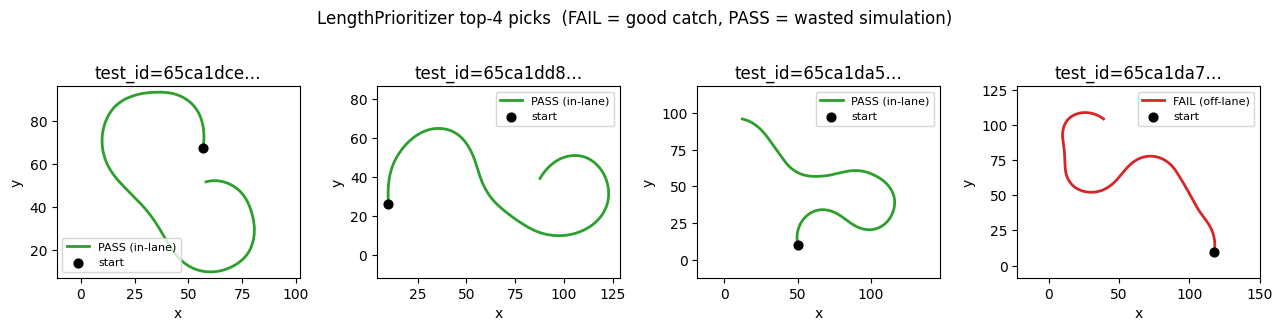

In [10]:
# Inspect LengthPrioritizer's top picks (the worked example above).
plot_top_picks(report_length, test_suite, ground_truth, k=4)
plt.show()

## 7. Submission

When you are happy with your `MyPrioritizer`:

1. Make sure the **Section 5** cell runs cleanly (no exceptions from the validity check).
2. Note your **APFD** and **APFDC** numbers — these are the scoreboard metrics.
3. Save the notebook with your final code and **the printed evaluation report visible**.
4. Add a short markdown cell explaining your approach in 2-3 sentences.

See `../1_challenge_guide.md` for the full ranking rules.